# **1) Imports + configuración global**


## 1.1) Imports


In [1]:
import os, time, math, json, copy, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image, ImageOps
import pennylane as qml
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, accuracy_score, balanced_accuracy_score, f1_score, precision_score, confusion_matrix, classification_report

## 1.2) Identidad del experimento


In [2]:
EXPERIMENT_NAME = "OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN"
MODEL_NAME = "MS-HQCNN -> z15 -> SU(4)-QNN | OCT2017 CNV vs NORMAL"

## 1.3) Semilla


In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True; torch.set_default_dtype(torch.float32)

## 1.4) Device


In [4]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
PL_TORCH_DEVICE = "cuda" if DEVICE.type == "cuda" else "cpu"
print(f"[Experimento] {EXPERIMENT_NAME}\n[Modelo] {MODEL_NAME}\n[Device] {DEVICE}\n[PennyLane torch_device] {PL_TORCH_DEVICE}\n[CUDA available] {torch.cuda.is_available()}")
if torch.cuda.is_available(): print("[CUDA device]", torch.cuda.get_device_name(0))

[Experimento] OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN
[Modelo] MS-HQCNN -> z15 -> SU(4)-QNN | OCT2017 CNV vs NORMAL
[Device] cuda:0
[PennyLane torch_device] cuda
[CUDA available] True
[CUDA device] NVIDIA GeForce RTX 3090


## 1.5) Ruta del dataset


In [5]:
DATA_ROOT = r"C:\Users\lapic\datasets\OCT2017\OCT2017_Gray256"
META_PATH = r"C:\Users\lapic\datasets\OCT2017\oct2017_gray256_3000_per_class_metadata.csv"

if not os.path.isdir(DATA_ROOT):
    raise FileNotFoundError(f"No encontré DATA_ROOT:\n{DATA_ROOT}")

if not os.path.isfile(META_PATH):
    raise FileNotFoundError(f"No encontré META_PATH:\n{META_PATH}")

print("[DATA_ROOT]", DATA_ROOT)
print("[META_PATH]", META_PATH)

[DATA_ROOT] C:\Users\lapic\datasets\OCT2017\OCT2017_Gray256
[META_PATH] C:\Users\lapic\datasets\OCT2017\oct2017_gray256_3000_per_class_metadata.csv


## 1.6) Parámetros de datos


In [6]:
IMG_SIZE, IN_CHANNELS, BATCH_SIZE, NUM_WORKERS, FRAC_TRAIN, FRAC_VAL = 256, 1, 16, 0, 0.80, 0.10

## 1.7) Parámetros MS-HQCNN

In [7]:
LATENT_DIM, DROPOUT_P, LR_Q, LR_CL, WEIGHT_DECAY, QUBITS, LAYERS, SHOTS, DIFF_METHOD, CHUNK_PATCHES = 15, 0.20, 3e-4, 1e-3, 1e-5, 4, 2, None, "backprop", 1048576

## 1.8) Parámetros SU(4)-QNN


In [8]:
N_QUBITS, N_QNN_LAYERS, SU4_PARAMS, CNN_LR, QNN_LR, EPOCHS = 2, 7, 15, 1e-4, 5e-3, 50

## 1.9) Etiquetas


In [9]:
LABEL_NEG, LABEL_POS = -1, 1
NEGATIVE_CLASS, POSITIVE_CLASS = "NORMAL", "CNV"
CLASS_NAMES = {LABEL_NEG: NEGATIVE_CLASS, LABEL_POS: POSITIVE_CLASS}
TARGET_NAMES = [NEGATIVE_CLASS, POSITIVE_CLASS]
print(f"Clase negativa y=-1: {NEGATIVE_CLASS}\nClase positiva y=+1: {POSITIVE_CLASS}")

Clase negativa y=-1: NORMAL
Clase positiva y=+1: CNV


## 1.10) Carpetas de resultados


In [10]:
RESULTS_ROOT, MODEL_RESULTS_DIR = "Results", os.path.join("Results", EXPERIMENT_NAME)
CKPT_DIR, EMB_DIR, FIG_DIR, LOG_DIR, TABLE_DIR = os.path.join(MODEL_RESULTS_DIR, "checkpoints"), os.path.join(MODEL_RESULTS_DIR, "embeddings"), os.path.join(MODEL_RESULTS_DIR, "figures"), os.path.join(MODEL_RESULTS_DIR, "logs"), os.path.join(MODEL_RESULTS_DIR, "tables")
for d in [RESULTS_ROOT, MODEL_RESULTS_DIR, CKPT_DIR, EMB_DIR, FIG_DIR, LOG_DIR, TABLE_DIR]: os.makedirs(d, exist_ok=True)

## 1.11) Resumen


In [11]:
print("\n[Resumen]")
print(f"IMG_SIZE          = {IMG_SIZE}\nIN_CHANNELS       = {IN_CHANNELS}\nBATCH_SIZE        = {BATCH_SIZE}\nNUM_WORKERS       = {NUM_WORKERS}\nFRAC_TRAIN        = {FRAC_TRAIN}\nFRAC_VAL          = {FRAC_VAL}\nEPOCHS            = {EPOCHS}\nLATENT_DIM        = {LATENT_DIM}\nMS-HQCNN QUBITS   = {QUBITS}\nMS-HQCNN LAYERS   = {LAYERS}\nSHOTS             = {SHOTS}\nDIFF_METHOD       = {DIFF_METHOD}\nCHUNK_PATCHES     = {CHUNK_PATCHES}\nSU4 N_QUBITS      = {N_QUBITS}\nSU4 N_QNN_LAYERS  = {N_QNN_LAYERS}\nSU4 PARAMS        = {SU4_PARAMS}\nLR_Q              = {LR_Q}\nLR_CL             = {LR_CL}\nCNN_LR            = {CNN_LR}\nQNN_LR            = {QNN_LR}\nWEIGHT_DECAY      = {WEIGHT_DECAY}\nDROPOUT_P         = {DROPOUT_P}\nRESULTS_ROOT      = {RESULTS_ROOT}\nMODEL_RESULTS_DIR = {MODEL_RESULTS_DIR}\nCKPT_DIR          = {CKPT_DIR}\nEMB_DIR           = {EMB_DIR}\nFIG_DIR           = {FIG_DIR}\nLOG_DIR           = {LOG_DIR}\nTABLE_DIR         = {TABLE_DIR}")


[Resumen]
IMG_SIZE          = 256
IN_CHANNELS       = 1
BATCH_SIZE        = 16
NUM_WORKERS       = 0
FRAC_TRAIN        = 0.8
FRAC_VAL          = 0.1
EPOCHS            = 50
LATENT_DIM        = 15
MS-HQCNN QUBITS   = 4
MS-HQCNN LAYERS   = 2
SHOTS             = None
DIFF_METHOD       = backprop
CHUNK_PATCHES     = 1048576
SU4 N_QUBITS      = 2
SU4 N_QNN_LAYERS  = 7
SU4 PARAMS        = 15
LR_Q              = 0.0003
LR_CL             = 0.001
CNN_LR            = 0.0001
QNN_LR            = 0.005
WEIGHT_DECAY      = 1e-05
DROPOUT_P         = 0.2
RESULTS_ROOT      = Results
MODEL_RESULTS_DIR = Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN
CKPT_DIR          = Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\checkpoints
EMB_DIR           = Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\embeddings
FIG_DIR           = Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\figures
LOG_DIR           = Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\logs
TABLE_DIR         = Results\OCT2017_CNV_NORMAL_MS_H

# **2) Dataset + transforms + splits + dataloaders**


## 2.1) Transformaciones


In [12]:
train_tfms = transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
eval_tfms = transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])

## 2.2) Cargar metadata OCT2017 Gray256


In [13]:
df_meta = pd.read_csv(META_PATH)
print("[Metadata OCT2017]")
print(f"Total filas: {len(df_meta)}\n\nColumnas:\n{df_meta.columns.tolist()}")
print(f"\nPor clase:\n{df_meta['class'].value_counts()}")
print(f"\nPacientes únicos por clase:\n{df_meta.groupby('class')['patient_id'].nunique()}")
required_cols = {"gray256_path", "class", "patient_id"}
missing_cols = required_cols - set(df_meta.columns)
if missing_cols: raise ValueError(f"Faltan columnas en metadata: {missing_cols}")
df_meta["gray256_path"] = df_meta["gray256_path"].astype(str)
df_meta["class"] = df_meta["class"].astype(str)
df_meta["patient_id"] = df_meta["patient_id"].astype(str)
missing_files = df_meta[~df_meta["gray256_path"].apply(os.path.isfile)]
print(f"\nArchivos faltantes: {len(missing_files)}")
if len(missing_files) > 0:
    display(missing_files.head())
    raise FileNotFoundError("Hay imágenes en metadata que no existen en disco.")

[Metadata OCT2017]
Total filas: 12000

Columnas:
['path', 'filename', 'class', 'class_from_name', 'split_original', 'patient_id', 'image_id', 'gray256_path']

Por clase:
class
CNV       3000
DME       3000
DRUSEN    3000
NORMAL    3000
Name: count, dtype: int64

Pacientes únicos por clase:
class
CNV        969
DME        876
DRUSEN     882
NORMAL    3000
Name: patient_id, dtype: int64

Archivos faltantes: 0


## 2.3) Seleccionar clases binarias OCT


In [14]:
selected_classes = [NEGATIVE_CLASS, POSITIVE_CLASS]
df_bin = df_meta[df_meta["class"].isin(selected_classes)].copy().reset_index(drop=True)
label_map = {NEGATIVE_CLASS: LABEL_NEG, POSITIVE_CLASS: LABEL_POS}
df_bin["label"] = df_bin["class"].map(label_map).astype(int)
df_bin["label01"] = (df_bin["label"] == LABEL_POS).astype(int)
print("[Clasificación binaria OCT]")
print(f"Clase negativa y=-1: {NEGATIVE_CLASS}\nClase positiva y=+1: {POSITIVE_CLASS}")
print(f"\nImágenes por clase:\n{df_bin['class'].value_counts()}")
print(f"\nPacientes por clase:\n{df_bin.groupby('class')['patient_id'].nunique()}")
print(f"\nTotal binario: {len(df_bin)}")

[Clasificación binaria OCT]
Clase negativa y=-1: NORMAL
Clase positiva y=+1: CNV

Imágenes por clase:
class
CNV       3000
NORMAL    3000
Name: count, dtype: int64

Pacientes por clase:
class
CNV        969
NORMAL    3000
Name: patient_id, dtype: int64

Total binario: 6000


## 2.4) Dataset binario desde metadata

In [15]:
class OCTMetadataBipolarDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["gray256_path"]).convert("L")
        if self.transform is not None: img = self.transform(img)
        return img, torch.tensor(int(row["label"]), dtype=torch.float32)

binary_ds = OCTMetadataBipolarDataset(df_bin, transform=train_tfms)
labels_all = df_bin["label"].values.astype(int)
labels_all_01 = df_bin["label01"].values.astype(int)
n_total, n_pos, n_neg = len(labels_all), int(np.sum(labels_all == LABEL_POS)), int(np.sum(labels_all == LABEL_NEG))
print("[Dataset binario]")
print(f"Total: {n_total}\nNegativos y=-1 ({NEGATIVE_CLASS}): {n_neg}\nPositivos y=+1 ({POSITIVE_CLASS}): {n_pos}\nProporción positivos: {100*n_pos/n_total:.2f}%")

[Dataset binario]
Total: 6000
Negativos y=-1 (NORMAL): 3000
Positivos y=+1 (CNV): 3000
Proporción positivos: 50.00%


## 2.5) Split train / val / test por paciente, sin leakage


In [16]:
df_bin["case_id"] = df_bin["class"].astype(str) + "_" + df_bin["patient_id"].astype(str)
case_df = df_bin[["case_id", "patient_id", "label01", "class"]].drop_duplicates(subset=["case_id"]).reset_index(drop=True)
print("[Casos/pacientes para split]")
print(case_df.groupby("class")["case_id"].nunique())
patient_class_counts = df_bin[["patient_id", "class"]].drop_duplicates().groupby("patient_id")["class"].nunique()
overlap_numeric_ids = int((patient_class_counts > 1).sum())
print(f"\nPatient_id numéricos presentes en más de una clase: {overlap_numeric_ids}")
print("Usaremos case_id = class + '_' + patient_id para evitar falsas colisiones.")

cases, case_targets = case_df["case_id"].values, case_df["label01"].values
train_cases, tmp_cases, y_train_c, y_tmp_c = train_test_split(cases, case_targets, train_size=FRAC_TRAIN, random_state=SEED, stratify=case_targets)
val_fraction_of_tmp = FRAC_VAL / (1.0 - FRAC_TRAIN)
val_cases, test_cases, y_val_c, y_test_c = train_test_split(tmp_cases, y_tmp_c, train_size=val_fraction_of_tmp, random_state=SEED, stratify=y_tmp_c)
train_cases, val_cases, test_cases = set(train_cases), set(val_cases), set(test_cases)
assert len(train_cases & val_cases) == 0 and len(train_cases & test_cases) == 0 and len(val_cases & test_cases) == 0

idx_train, idx_val, idx_test = df_bin.index[df_bin["case_id"].isin(train_cases)].to_numpy(), df_bin.index[df_bin["case_id"].isin(val_cases)].to_numpy(), df_bin.index[df_bin["case_id"].isin(test_cases)].to_numpy()
train_ds, val_ds, test_ds = Subset(binary_ds, idx_train), Subset(binary_ds, idx_val), Subset(binary_ds, idx_test)

def split_report(name, idxs):
    sub = df_bin.iloc[idxs]
    total, pos, neg, n_cases, n_patient_ids = len(sub), int((sub["label"] == LABEL_POS).sum()), int((sub["label"] == LABEL_NEG).sum()), sub["case_id"].nunique(), sub["patient_id"].nunique()
    print(f"{name:>5}: total={total:5d} | cases={n_cases:5d} | patient_ids={n_patient_ids:5d} | y=-1 {neg:5d} | y=+1 {pos:5d} | pos={100*pos/total:5.2f}%")

print("\n[Splits por case_id]")
split_report("train", idx_train); split_report("val", idx_val); split_report("test", idx_test)
print("\n[Leakage check por case_id]")
print(f"train ∩ val : {len(train_cases & val_cases)}\ntrain ∩ test: {len(train_cases & test_cases)}\nval ∩ test  : {len(val_cases & test_cases)}")

[Casos/pacientes para split]
class
CNV        969
NORMAL    3000
Name: case_id, dtype: int64

Patient_id numéricos presentes en más de una clase: 145
Usaremos case_id = class + '_' + patient_id para evitar falsas colisiones.

[Splits por case_id]
train: total= 4784 | cases= 3175 | patient_ids= 3086 | y=-1  2400 | y=+1  2384 | pos=49.83%
  val: total=  614 | cases=  397 | patient_ids=  396 | y=-1   300 | y=+1   314 | pos=51.14%
 test: total=  602 | cases=  397 | patient_ids=  395 | y=-1   300 | y=+1   302 | pos=50.17%

[Leakage check por case_id]
train ∩ val : 0
train ∩ test: 0
val ∩ test  : 0


## 2.6) DataLoaders

In [17]:
g_cpu = torch.Generator(device="cpu"); g_cpu.manual_seed(SEED)
loader_kwargs_train = {"batch_size": BATCH_SIZE, "shuffle": True, "generator": g_cpu, "num_workers": NUM_WORKERS, "pin_memory": (DEVICE.type == "cuda")}
loader_kwargs_eval = {"batch_size": BATCH_SIZE, "shuffle": False, "num_workers": NUM_WORKERS, "pin_memory": (DEVICE.type == "cuda")}
if NUM_WORKERS > 0:
    loader_kwargs_train["persistent_workers"] = loader_kwargs_eval["persistent_workers"] = True
    loader_kwargs_train["prefetch_factor"] = loader_kwargs_eval["prefetch_factor"] = 2
train_loader = DataLoader(train_ds, **loader_kwargs_train)
val_loader = DataLoader(val_ds, **loader_kwargs_eval)
test_loader = DataLoader(test_ds, **loader_kwargs_eval)
print(f"\n[DataLoaders]\nNUM_WORKERS   = {NUM_WORKERS}\nBATCH_SIZE    = {BATCH_SIZE}\nTrain batches = {len(train_loader)}\nVal batches   = {len(val_loader)}\nTest batches  = {len(test_loader)}")


[DataLoaders]
NUM_WORKERS   = 0
BATCH_SIZE    = 16
Train batches = 299
Val batches   = 39
Test batches  = 38


## 2.7) Sanity check de datos


In [18]:
xb, yb = next(iter(train_loader))
print("\n[Sanity batch]")
print(f"x shape: {xb.shape}\ny shape: {yb.shape}\nx dtype: {xb.dtype}\ny dtype: {yb.dtype}\nx min/max: {float(xb.min())} {float(xb.max())}\ny unique: {torch.unique(yb)}")


[Sanity batch]
x shape: torch.Size([16, 1, 256, 256])
y shape: torch.Size([16])
x dtype: torch.float32
y dtype: torch.float32
x min/max: -1.0 1.0
y unique: tensor([-1.,  1.])


## 2.8) Visualización rápida


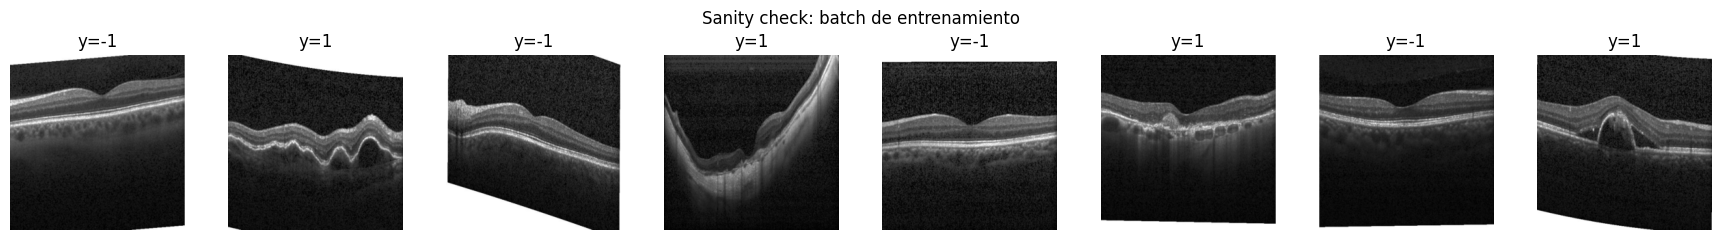

In [19]:
n_show = min(8, xb.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(2.2*n_show, 2.4))
if n_show == 1: axes = [axes]
for i in range(n_show):
    img, label = xb[i, 0].detach().cpu().numpy(), int(yb[i].item())
    axes[i].imshow(img, cmap="gray"); axes[i].set_title(f"y={label}"); axes[i].axis("off")
plt.suptitle("Sanity check: batch de entrenamiento"); plt.tight_layout(); plt.show()

# **3) Métricas + checkpoints + gráficas**


## 3.1) Utilidades generales


In [20]:
def count_parameters(model):
    total, trainable = sum(p.numel() for p in model.parameters()), sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def clone_state_dict_cpu(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def bipolar_to_binary(y):
    y = np.asarray(y).astype(int)
    return (y == LABEL_POS).astype(int)

def qscore_to_probs(q_scores):
    q_scores = np.asarray(q_scores).astype(float)
    return np.clip(0.5 * (q_scores + 1.0), 0.0, 1.0)

## 3.2) Métricas binarias


In [21]:
def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    return np.nan if len(np.unique(y_true)) < 2 else roc_auc_score(y_true, y_score)

def safe_pr_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    return np.nan if len(np.unique(y_true)) < 2 else average_precision_score(y_true, y_score)

def binary_metrics_from_probs(y_true, probs, threshold=0.5):
    y_true, probs = np.asarray(y_true).astype(int), np.asarray(probs).astype(float)
    y_pred = (probs >= threshold).astype(int)
    acc, f1, prec, bacc = accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, zero_division=0), precision_score(y_true, y_pred, zero_division=0), balanced_accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity, specificity = tp / (tp + fn + 1e-12), tn / (tn + fp + 1e-12)
    return {"threshold": float(threshold), "acc": float(acc), "f1": float(f1), "precision": float(prec), "bacc": float(bacc), "sensitivity": float(sensitivity), "specificity": float(specificity), "pred1": float(y_pred.mean()), "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

def binary_metrics_from_qscores(y_true_bipolar, q_scores, threshold=0.0):
    y_true_bipolar, q_scores = np.asarray(y_true_bipolar).astype(int), np.asarray(q_scores).astype(float)
    y_true_01, probs = bipolar_to_binary(y_true_bipolar), qscore_to_probs(q_scores)
    return binary_metrics_from_probs(y_true_01, probs, threshold=0.5 * (threshold + 1.0))

## 3.3) Búsqueda de threshold óptimo


In [22]:
def find_best_threshold(y_true, probs, metric="bacc"):
    probs = np.asarray(probs).astype(float)
    thresholds = np.unique(probs)
    if len(thresholds) > 1000: thresholds = np.linspace(0.0, 1.0, 1001)
    best_thr, best_val, best_metrics = 0.5, -np.inf, None
    for thr in thresholds:
        m = binary_metrics_from_probs(y_true, probs, threshold=thr)
        val = m[metric]
        if val > best_val: best_val, best_thr, best_metrics = val, float(thr), m
    return best_thr, best_metrics

## 3.4) Evaluación completa para salida SU(4)


In [23]:
def evaluate_qnn_outputs(y_true_bipolar, q_scores):
    y_true_bipolar, q_scores = np.asarray(y_true_bipolar).astype(int), np.asarray(q_scores).astype(float)
    y_true_01, probs = bipolar_to_binary(y_true_bipolar), qscore_to_probs(q_scores)
    auc, pr_auc = safe_auc(y_true_01, probs), safe_pr_auc(y_true_01, probs)
    m05 = binary_metrics_from_probs(y_true_01, probs, threshold=0.5)
    thr_star, mstar = find_best_threshold(y_true_01, probs, metric="bacc")
    return {"auc": float(auc), "pr_auc": float(pr_auc), "probs": probs, "q_scores": q_scores, "m05": m05, "thr_star": float(thr_star), "q_thr_star": float(2.0*thr_star - 1.0), "mstar": mstar}

## 3.5) Loss

In [24]:
def camila_mse_loss(q_outputs, y_bipolar):
    return torch.mean((q_outputs.float() - y_bipolar.float()) ** 2)

## 3.6) Formato de impresión por época

In [25]:
def format_epoch_line(epoch, dt, train_loss, train_acc05, val_loss, val_eval, lr_q, lr_cl):
    m05, ms = val_eval["m05"], val_eval["mstar"]
    return f"Época {epoch:02d} (dt={dt:.1f}s) | Train loss={train_loss:.4f} acc@0={100*train_acc05:.1f}% | Val loss={val_loss:.4f} AUC={val_eval['auc']:.3f} PR-AUC={val_eval['pr_auc']:.3f} | @0 acc={100*m05['acc']:.1f}% F1={m05['f1']:.3f} bAcc={m05['bacc']:.3f} pred1={100*m05['pred1']:.1f}% | @thr* acc={100*ms['acc']:.1f}% F1={ms['f1']:.3f} bAcc={ms['bacc']:.3f} pred1={100*ms['pred1']:.1f}% q_thr={val_eval['q_thr_star']:.3f} | LR_Q={lr_q:.2e} | LR_CL={lr_cl:.2e}"

## 3.7) Checkpoints


In [26]:
def save_checkpoint(path, model, optimizer, epoch, metrics, threshold=None):
    torch.save({"experiment_name": EXPERIMENT_NAME, "model_name": MODEL_NAME, "epoch": epoch, "model_state_dict": clone_state_dict_cpu(model), "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None, "metrics": metrics, "threshold": threshold}, path)

def load_model_state_from_checkpoint(model, path, map_location=DEVICE):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state_dict"])
    return ckpt

## 3.8) Gráficas de entrenamiento


In [27]:
def plot_history(history, fig_dir=FIG_DIR, prefix="train"):
    df = pd.DataFrame(history)
    if len(df) == 0: return
    plt.figure(figsize=(7, 5))
    plt.plot(df["epoch"], df["train_loss"], marker="o", label="Train")
    plt.plot(df["epoch"], df["val_loss"], marker="o", label="Val")
    plt.title(f"{MODEL_NAME} - Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"{prefix}_loss.png"), dpi=160); plt.show()
    plt.figure(figsize=(7, 5))
    plt.plot(df["epoch"], 100*df["train_acc05"], marker="o", label="Train")
    plt.plot(df["epoch"], 100*df["val_acc05"], marker="o", label="Val @0")
    plt.plot(df["epoch"], 100*df["val_acc_thr"], marker="o", label="Val @thr*")
    plt.title(f"{MODEL_NAME} - Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"{prefix}_accuracy.png"), dpi=160); plt.show()

## 3.9) Curvas ROC / PR y matriz de confusión

In [28]:
def plot_eval_curves(y_true_bipolar, q_scores, threshold=0.0, split_name="test", fig_dir=FIG_DIR, prefix="eval"):
    y_true_bipolar, q_scores = np.asarray(y_true_bipolar).astype(int), np.asarray(q_scores).astype(float)
    y_true_01, probs = bipolar_to_binary(y_true_bipolar), qscore_to_probs(q_scores)
    if len(np.unique(y_true_01)) == 2:
        fpr, tpr, _ = roc_curve(y_true_01, probs)
        auc = roc_auc_score(y_true_01, probs)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        plt.plot([0, 1], [0, 1], "--")
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC - {split_name}"); plt.legend(); plt.grid(True); plt.tight_layout()
        plt.savefig(os.path.join(fig_dir, f"{prefix}_{split_name}_roc.png"), dpi=160); plt.show()
        precision, recall, _ = precision_recall_curve(y_true_01, probs)
        pr_auc = average_precision_score(y_true_01, probs)
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"PR-AUC={pr_auc:.3f}")
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"PR curve - {split_name}"); plt.legend(); plt.grid(True); plt.tight_layout()
        plt.savefig(os.path.join(fig_dir, f"{prefix}_{split_name}_pr.png"), dpi=160); plt.show()
    y_pred_01 = (q_scores >= threshold).astype(int)
    cm = confusion_matrix(y_true_01, y_pred_01, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion matrix - {split_name}"); plt.colorbar()
    plt.xticks([0, 1], TARGET_NAMES, rotation=45)
    plt.yticks([0, 1], TARGET_NAMES)
    plt.ylabel("True label"); plt.xlabel("Predicted label")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"{prefix}_{split_name}_cm.png"), dpi=160); plt.show()

## 3.10) Guardar configuración


In [29]:
config_path = os.path.join(LOG_DIR, "config.json")
config_dict = {"experiment_name": EXPERIMENT_NAME, "model_name": MODEL_NAME, "data_root": DATA_ROOT, "metadata_path": META_PATH, "negative_class": NEGATIVE_CLASS, "positive_class": POSITIVE_CLASS, "seed": SEED, "img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "epochs": EPOCHS, "latent_dim": LATENT_DIM, "mshqcnn_qubits": QUBITS, "mshqcnn_layers": LAYERS, "chunk_patches": CHUNK_PATCHES, "su4_qubits": N_QUBITS, "su4_layers": N_QNN_LAYERS, "su4_params": SU4_PARAMS, "label_neg": LABEL_NEG, "label_pos": LABEL_POS}
with open(config_path, "w", encoding="utf-8") as f: json.dump(config_dict, f, indent=2, ensure_ascii=False)
print("[OK] Sección 3 lista")
print("Config:", config_path)

[OK] Sección 3 lista
Config: Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\logs\config.json


# **4) Backend cuántico MS-HQCNN + quanvolution normal/grupal**

## 4.1) Dispositivo PennyLane para MS-HQCNN


In [30]:
mshqcnn_qdev = qml.device("default.qubit.torch", wires=QUBITS, shots=SHOTS, torch_device=PL_TORCH_DEVICE)
print("[Sección 4] Backend cuántico MS-HQCNN")
print(f"PennyLane device: {mshqcnn_qdev}\nPL_TORCH_DEVICE: {PL_TORCH_DEVICE}\nQUBITS: {QUBITS}\nLAYERS: {LAYERS}\nSHOTS: {SHOTS}\nDIFF_METHOD: {DIFF_METHOD}\nCHUNK_PATCHES: {CHUNK_PATCHES}")

[Sección 4] Backend cuántico MS-HQCNN
PennyLane device: Default qubit (Torch) PennyLane plugin
Short name: default.qubit.torch
Package: pennylane
Plugin version: 0.37.0
Author: Xanadu Inc.
Wires: 4
Shots: None
PL_TORCH_DEVICE: cuda
QUBITS: 4
LAYERS: 2
SHOTS: None
DIFF_METHOD: backprop
CHUNK_PATCHES: 1048576


## 4.2) QNode batched rápido


In [31]:
@qml.qnode(mshqcnn_qdev, interface="torch", diff_method=DIFF_METHOD)
def quanv_circuit_batched_fixed4(angles_b, weights):
    for w in range(4):
        qml.RY(angles_b[:, w], wires=w)
    for l in range(LAYERS):
        for w in range(4):
            qml.RY(weights[l, w, 0], wires=w); qml.RZ(weights[l, w, 1], wires=w)
        qml.CNOT(wires=[0, 1]); qml.CNOT(wires=[1, 2]); qml.CNOT(wires=[2, 3]); qml.CNOT(wires=[3, 0])
    return tuple(qml.expval(qml.PauliZ(w)) for w in range(4))

## 4.3) Quanvolution normal


In [32]:
class Quanv2x2Stride2_1ch(nn.Module):
    def __init__(self, chunk_patches=CHUNK_PATCHES):
        super().__init__()
        self.chunk = chunk_patches
        self.weights = nn.Parameter(0.1 * torch.randn(LAYERS, 4, 2, dtype=torch.float32))
        self._dbg_printed = False

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        B, C, H, W = x.shape
        assert C == 1, f"Quanv normal espera C=1, recibió C={C}"
        if (H % 2) or (W % 2):
            x = F.pad(x, (0, W % 2, 0, H % 2), value=0.0); B, C, H, W = x.shape
        H2, W2 = H // 2, W // 2
        patches = x.view(B, 1, H2, 2, W2, 2).permute(0, 2, 4, 1, 3, 5).contiguous().reshape(B * H2 * W2, 4)
        angles = math.pi * patches
        outs = []
        N = angles.shape[0]
        for s in range(0, N, self.chunk):
            e = min(s + self.chunk, N)
            out_chunk = torch.stack(quanv_circuit_batched_fixed4(angles[s:e], self.weights), dim=1)
            outs.append(out_chunk)
        out = torch.cat(outs, dim=0).view(B, H2, W2, 4).permute(0, 3, 1, 2).contiguous().to(dtype=torch.float32)
        if not self._dbg_printed:
            print(f"[Quanv normal] input=({B},{C},{H},{W}) -> output={tuple(out.shape)} | chunk={self.chunk}")
            self._dbg_printed = True
        return out

## 4.4) Quanvolution grupal


In [33]:
class GroupQuanv2x2Stride2(nn.Module):
    def __init__(self, in_channels, group_size=4, n_meas=4, chunk_patches=CHUNK_PATCHES):
        super().__init__()
        assert in_channels % group_size == 0, f"in_channels={in_channels} debe ser divisible por group_size={group_size}"
        assert n_meas in [1, 2, 4], "n_meas debe ser 1, 2 o 4"
        self.in_channels, self.group_size, self.n_groups, self.n_meas, self.chunk = in_channels, group_size, in_channels // group_size, n_meas, chunk_patches
        self.proj = nn.Linear(4 * group_size, 4)
        self.weights = nn.Parameter(0.1 * torch.randn(LAYERS, 4, 2, dtype=torch.float32))
        self._dbg_printed = False

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        B, C, H, W = x.shape
        assert C == self.in_channels, f"Esperaba C={self.in_channels}, recibió C={C}"
        if (H % 2) or (W % 2):
            x = F.pad(x, (0, W % 2, 0, H % 2), value=0.0); B, C, H, W = x.shape
        H2, W2 = H // 2, W // 2
        x = x.view(B, C, H2, 2, W2, 2).permute(0, 2, 4, 1, 3, 5).contiguous().view(B, H2, W2, self.n_groups, self.group_size, 2, 2).reshape(B * H2 * W2 * self.n_groups, self.group_size * 4)
        angles = torch.tanh(self.proj(x)) * math.pi
        outs = []
        N = angles.shape[0]
        for s in range(0, N, self.chunk):
            e = min(s + self.chunk, N)
            out_chunk = torch.stack(quanv_circuit_batched_fixed4(angles[s:e], self.weights), dim=1)
            if self.n_meas < 4: out_chunk = out_chunk[:, :self.n_meas]
            outs.append(out_chunk)
        out = torch.cat(outs, dim=0).view(B, H2, W2, self.n_groups * self.n_meas).permute(0, 3, 1, 2).contiguous().to(dtype=torch.float32)
        if not self._dbg_printed:
            print(f"[Quanv grupal] Cin={self.in_channels}, g={self.group_size}, ng={self.n_groups}, n_meas={self.n_meas} -> Cout={self.n_groups*self.n_meas} | output={tuple(out.shape)} | chunk={self.chunk}")
            self._dbg_printed = True
        return out

## 4.5) Sanity check ligero


In [34]:
print("\n[Sanity check Sección 4]")
with torch.no_grad():
    q_normal = Quanv2x2Stride2_1ch(chunk_patches=CHUNK_PATCHES).to(DEVICE)
    x1 = torch.randn(1, 1, 32, 32, device=DEVICE)
    y1 = q_normal(x1)
    print("Quanv normal:\ninput : {tuple(x1.shape)}\noutput: {tuple(y1.shape)}")
    del q_normal, x1, y1
    q_group = GroupQuanv2x2Stride2(in_channels=16, group_size=4, n_meas=4, chunk_patches=CHUNK_PATCHES).to(DEVICE)
    xg = torch.randn(1, 16, 32, 32, device=DEVICE)
    yg = q_group(xg)
    print("\nQuanv grupal:\ninput : {tuple(xg.shape)}\noutput: {tuple(yg.shape)}")
    del q_group, xg, yg
if torch.cuda.is_available(): torch.cuda.empty_cache()
print("\n[OK] Sección 4 lista")


[Sanity check Sección 4]
[Quanv normal] input=(1,1,32,32) -> output=(1, 4, 16, 16) | chunk=1048576
Quanv normal:
input : {tuple(x1.shape)}
output: {tuple(y1.shape)}
[Quanv grupal] Cin=16, g=4, ng=4, n_meas=4 -> Cout=16 | output=(1, 16, 16, 16) | chunk=1048576

Quanv grupal:
input : {tuple(xg.shape)}
output: {tuple(yg.shape)}

[OK] Sección 4 lista


# **5) Extractor MS-HQCNN -> z15 sin MLP**


## 5.1) Bloque de mezcla clásica


In [35]:
class MixBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
    def forward(self, x):
        return self.block(x)

## 5.2) Etapa cuántica inicial


In [36]:
class QuantumStage1(nn.Module):
    def __init__(self):
        super().__init__()
        self.quanv = Quanv2x2Stride2_1ch(chunk_patches=CHUNK_PATCHES)
        self.mix = MixBlock(in_channels=4, out_channels=16)
    def forward(self, x):
        return self.mix(self.quanv(x))

## 5.3) Etapa cuántica intermedia


In [37]:
class QuantumStageGrouped(nn.Module):
    def __init__(self, in_channels, group_size, mix_out_channels):
        super().__init__()
        self.quanv = GroupQuanv2x2Stride2(in_channels=in_channels, group_size=group_size, n_meas=4, chunk_patches=CHUNK_PATCHES)
        self.mix = MixBlock(in_channels=(in_channels // group_size) * 4, out_channels=mix_out_channels)
    def forward(self, x):
        return self.mix(self.quanv(x))

## 5.4) MS-HQCNN como extractor z15


In [38]:
class MSHQCNN_Z15Extractor(nn.Module):
    def __init__(self, latent_dim=15):
        super().__init__()
        self.stage1 = QuantumStage1()
        self.stage2 = QuantumStageGrouped(in_channels=16, group_size=4, mix_out_channels=32)
        self.stage3 = QuantumStageGrouped(in_channels=32, group_size=4, mix_out_channels=latent_dim)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

    def forward(self, x, return_maps=False):
        maps = {}
        x = self.stage1(x); maps["stage1"] = x
        x = self.stage2(x); maps["stage2"] = x
        x = self.stage3(x); maps["stage3"] = x
        z15 = self.flatten(self.gap(x))
        return (z15, maps) if return_maps else z15

## 5.5) Crear extractor


In [39]:
mshqcnn_extractor = MSHQCNN_Z15Extractor(latent_dim=LATENT_DIM).to(DEVICE)
total_params, trainable_params = count_parameters(mshqcnn_extractor)
print("[MS-HQCNN extractor z15]")
print(f"Total params     : {total_params:,}\nTrainable params : {trainable_params:,}")

[MS-HQCNN extractor z15]
Total params     : 1,366
Trainable params : 1,366


## 5.6) Separar parámetros cuánticos y clásicos del extractor


In [40]:
mshqcnn_quantum_params, mshqcnn_classical_params = [], []
for name, param in mshqcnn_extractor.named_parameters():
    if not param.requires_grad: continue
    if "weights" in name: mshqcnn_quantum_params.append(param)
    else: mshqcnn_classical_params.append(param)
n_q_mshqcnn, n_c_mshqcnn = sum(p.numel() for p in mshqcnn_quantum_params), sum(p.numel() for p in mshqcnn_classical_params)
print(f"MS-HQCNN quantum params   : {n_q_mshqcnn:,}\nMS-HQCNN classical params : {n_c_mshqcnn:,}")

MS-HQCNN quantum params   : 48
MS-HQCNN classical params : 1,318


## 5.7) Sanity check dimensional MS-HQCNN -> z15


In [41]:
print("\n[Sanity check Sección 5]")
with torch.no_grad():
    xb_sanity, yb_sanity = next(iter(train_loader))
    xb_sanity = xb_sanity.to(DEVICE)
    z_sanity, maps_sanity = mshqcnn_extractor(xb_sanity, return_maps=True)
print(f"Entrada : {tuple(xb_sanity.shape)}\nStage 1 : {tuple(maps_sanity['stage1'].shape)}\nStage 2 : {tuple(maps_sanity['stage2'].shape)}\nStage 3 : {tuple(maps_sanity['stage3'].shape)}\nz15     : {tuple(z_sanity.shape)}\nz min   : {float(z_sanity.min())}\nz max   : {float(z_sanity.max())}\ny       : {tuple(yb_sanity.shape)}\nlabels  : {torch.unique(yb_sanity)}")
del xb_sanity, yb_sanity, z_sanity, maps_sanity
if torch.cuda.is_available(): torch.cuda.empty_cache()
print("\n[OK] Sección 5 lista")


[Sanity check Sección 5]
[Quanv normal] input=(16,1,256,256) -> output=(16, 4, 128, 128) | chunk=1048576
[Quanv grupal] Cin=16, g=4, ng=4, n_meas=4 -> Cout=16 | output=(16, 16, 64, 64) | chunk=1048576
[Quanv grupal] Cin=32, g=4, ng=8, n_meas=4 -> Cout=32 | output=(16, 32, 32, 32) | chunk=1048576
Entrada : (16, 1, 256, 256)
Stage 1 : (16, 16, 128, 128)
Stage 2 : (16, 32, 64, 64)
Stage 3 : (16, 15, 32, 32)
z15     : (16, 15)
z min   : 0.1671428084373474
z max   : 0.7698173522949219
y       : (16,)
labels  : tensor([-1.,  1.])

[OK] Sección 5 lista


# **6) SU(4)-QNN batched**


## 6.1) Dispositivo cuántico SU(4)


In [42]:
su4_qdev = qml.device("default.qubit.torch", wires=N_QUBITS, torch_device=str(DEVICE))
QDEVICE_NAME = "default.qubit.torch"
print("[Sección 6] Quantum device SU(4)")
print(f"Backend     : {QDEVICE_NAME}\nWires       : {N_QUBITS}\nInterface   : torch\nDiff method : backprop")

[Sección 6] Quantum device SU(4)
Backend     : default.qubit.torch
Wires       : 2
Interface   : torch
Diff method : backprop


## 6.2) SU(4) data encoding z15

In [43]:
def su4_data_encoding(z):
    qml.Rot(z[:, 0], z[:, 1], z[:, 2], wires=0)
    qml.Rot(z[:, 3], z[:, 4], z[:, 5], wires=1)
    qml.IsingXX(z[:, 6], wires=[0, 1])
    qml.IsingYY(z[:, 7], wires=[0, 1])
    qml.IsingZZ(z[:, 8], wires=[0, 1])
    qml.Rot(z[:, 9], z[:, 10], z[:, 11], wires=0)
    qml.Rot(z[:, 12], z[:, 13], z[:, 14], wires=1)

## 6.3) Bloque variacional SU(4)

In [44]:
def su4_variational_block(theta_layer):
    qml.Rot(theta_layer[0], theta_layer[1], theta_layer[2], wires=0)
    qml.Rot(theta_layer[3], theta_layer[4], theta_layer[5], wires=1)
    qml.IsingXX(theta_layer[6], wires=[0, 1])
    qml.IsingYY(theta_layer[7], wires=[0, 1])
    qml.IsingZZ(theta_layer[8], wires=[0, 1])
    qml.Rot(theta_layer[9], theta_layer[10], theta_layer[11], wires=0)
    qml.Rot(theta_layer[12], theta_layer[13], theta_layer[14], wires=1)

## 6.4) Batched SU(4) QNode

In [45]:
@qml.qnode(su4_qdev, interface="torch", diff_method="backprop")
def su4_qnode(z, theta):
    for layer in range(N_QNN_LAYERS):
        su4_data_encoding(z)
        su4_variational_block(theta[layer])
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

## 6.5) Módulo SU(4)-QNN

In [46]:
class SU4QNNLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(0.01 * torch.randn(N_QNN_LAYERS, SU4_PARAMS, dtype=torch.float32))
    def forward(self, z):
        return su4_qnode(torch.pi * torch.tanh(z), self.theta)

## 6.6) Crear SU(4)-QNN


In [47]:
su4_qnn = SU4QNNLayer().to(DEVICE)
total_su4_params, trainable_su4_params = count_parameters(su4_qnn)
print(f"\n[SU(4)-QNN]\nTotal params     : {total_su4_params:,}\nTrainable params : {trainable_su4_params:,}\ntheta shape      : {tuple(su4_qnn.theta.shape)}")


[SU(4)-QNN]
Total params     : 105
Trainable params : 105
theta shape      : (7, 15)


## 6.7) Sanity check MS-HQCNN -> z15 -> SU(4)

In [48]:
print("\n[Sanity check Sección 6]")
mshqcnn_extractor.eval(); su4_qnn.eval()
with torch.no_grad():
    xb_sanity, yb_sanity = next(iter(train_loader))
    xb_sanity, yb_sanity = xb_sanity.to(DEVICE), yb_sanity.to(DEVICE)
    z_sanity = mshqcnn_extractor(xb_sanity)
    q_sanity = su4_qnn(z_sanity)
    loss_sanity = camila_mse_loss(q_sanity, yb_sanity)
print(f"x shape        : {tuple(xb_sanity.shape)}\nz15 shape      : {tuple(z_sanity.shape)}\nq output shape : {tuple(q_sanity.shape)}\ny shape        : {tuple(yb_sanity.shape)}\nq min          : {float(q_sanity.min())}\nq max          : {float(q_sanity.max())}\nloss sanity    : {float(loss_sanity)}\ntheta shape    : {tuple(su4_qnn.theta.shape)}\ntheta device   : {su4_qnn.theta.device}")
del xb_sanity, yb_sanity, z_sanity, q_sanity, loss_sanity
if torch.cuda.is_available(): torch.cuda.empty_cache()
print("\n[OK] Sección 6 lista")


[Sanity check Sección 6]
x shape        : (16, 1, 256, 256)
z15 shape      : (16, 15)
q output shape : (16,)
y shape        : (16,)
q min          : 0.5236575827497696
q max          : 0.5643634009037513
loss sanity    : 1.5774270296096802
theta shape    : (7, 15)
theta device   : cuda:0

[OK] Sección 6 lista


# **7) Modelo combinado MS-HQCNN -> z15 -> SU(4)-QNN**


## 7.1) Wrapper completo


In [49]:
class MSHQCNN_SU4QNN(nn.Module):
    def __init__(self, extractor, su4_layer):
        super().__init__()
        self.extractor, self.su4_layer = extractor, su4_layer

    def forward(self, x, return_z=False):
        z15 = self.extractor(x)
        q_scores = self.su4_layer(z15)
        return (q_scores, z15) if return_z else q_scores

## 7.2) Crear modelo combinado


In [50]:
model = MSHQCNN_SU4QNN(extractor=mshqcnn_extractor, su4_layer=su4_qnn).to(DEVICE)
total_params, trainable_params = count_parameters(model)
print("[Modelo combinado]")
print(f"Total params     : {total_params:,}\nTrainable params : {trainable_params:,}")

[Modelo combinado]
Total params     : 1,471
Trainable params : 1,471


## 7.3) Separar parámetros para optimizer


In [51]:
quantum_params, classical_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad: continue
    if "weights" in name or "theta" in name: quantum_params.append(param)
    else: classical_params.append(param)
n_quantum_params, n_classical_params = sum(p.numel() for p in quantum_params), sum(p.numel() for p in classical_params)
print("\n[Grupos de parámetros]")
print(f"Quantum params   : {n_quantum_params:,}\nClassical params : {n_classical_params:,}")


[Grupos de parámetros]
Quantum params   : 153
Classical params : 1,318


## 7.4) Optimizer


In [52]:
optimizer = optim.Adam([
    {"params": classical_params, "lr": LR_CL, "weight_decay": WEIGHT_DECAY},
    {"params": quantum_params, "lr": LR_Q, "weight_decay": 0.0},
])
print("\n[Optimizer]")
print(f"Classical LR: {LR_CL}\nQuantum LR  : {LR_Q}\nWeight decay: {WEIGHT_DECAY}")


[Optimizer]
Classical LR: 0.001
Quantum LR  : 0.0003
Weight decay: 1e-05


## 7.5) Sanity check final del modelo completo


In [53]:
print("\n[Sanity check Sección 7]")
model.eval()
with torch.no_grad():
    xb_sanity, yb_sanity = next(iter(train_loader))
    xb_sanity, yb_sanity = xb_sanity.to(DEVICE), yb_sanity.to(DEVICE)
    q_sanity, z_sanity = model(xb_sanity, return_z=True)
    loss_sanity = camila_mse_loss(q_sanity, yb_sanity)
print(f"x shape        : {tuple(xb_sanity.shape)}\nz15 shape      : {tuple(z_sanity.shape)}\nq output shape : {tuple(q_sanity.shape)}\ny shape        : {tuple(yb_sanity.shape)}\nq min/max      : {float(q_sanity.min())} {float(q_sanity.max())}\nz min/max      : {float(z_sanity.min())} {float(z_sanity.max())}\nloss sanity    : {float(loss_sanity)}")
del xb_sanity, yb_sanity, q_sanity, z_sanity, loss_sanity
if torch.cuda.is_available(): torch.cuda.empty_cache()
print("\n[OK] Sección 7 lista")


[Sanity check Sección 7]
x shape        : (16, 1, 256, 256)
z15 shape      : (16, 15)
q output shape : (16,)
y shape        : (16,)
q min/max      : 0.5029373241602825 0.5589498765864943
z min/max      : 0.0 0.7215932607650757
loss sanity    : 1.1662579774856567

[OK] Sección 7 lista


# **8) Entrenamiento end-to-end**


## 8.1) Una época de entrenamiento


In [54]:
def train_one_epoch(model, loader, optimizer, device=DEVICE):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_q_scores, all_targets = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        q_scores = model(xb)
        loss = camila_mse_loss(q_scores, yb)
        loss.backward(); optimizer.step()
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size; total_samples += batch_size
        preds = torch.where(q_scores >= 0.0, torch.tensor(LABEL_POS, device=device, dtype=torch.float32), torch.tensor(LABEL_NEG, device=device, dtype=torch.float32))
        total_correct += (preds == yb).sum().item()
        all_q_scores.append(q_scores.detach().cpu().numpy()); all_targets.append(yb.detach().cpu().numpy())
    return total_loss / total_samples, total_correct / total_samples, np.concatenate(all_targets), np.concatenate(all_q_scores)

## 8.2) Evaluación por loader

In [55]:
@torch.no_grad()
def evaluate_loader(model, loader, device=DEVICE):
    model.eval()
    total_loss, total_samples = 0.0, 0
    all_q_scores, all_targets = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        q_scores = model(xb)
        loss = camila_mse_loss(q_scores, yb)
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size; total_samples += batch_size
        all_q_scores.append(q_scores.detach().cpu().numpy()); all_targets.append(yb.detach().cpu().numpy())
    all_q_scores, all_targets = np.concatenate(all_q_scores), np.concatenate(all_targets)
    return total_loss / total_samples, evaluate_qnn_outputs(all_targets, all_q_scores), all_targets, all_q_scores

## 8.3) Loop principal

In [56]:
history, best_val_bacc, best_epoch, best_threshold = [], -np.inf, -1, 0.0
best_ckpt_path, last_ckpt_path = os.path.join(CKPT_DIR, "best_model.pt"), os.path.join(CKPT_DIR, "last_model.pt")
print("[Entrenamiento]"); print(f"EPOCHS: {EPOCHS}\nBest checkpoint: {best_ckpt_path}")
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc0, train_y, train_q = train_one_epoch(model=model, loader=train_loader, optimizer=optimizer, device=DEVICE)
    val_loss, val_eval, val_y, val_q = evaluate_loader(model=model, loader=val_loader, device=DEVICE)
    dt = time.time() - t0
    val_acc0, val_acc_thr, val_bacc_thr = val_eval["m05"]["acc"], val_eval["mstar"]["acc"], val_eval["mstar"]["bacc"]
    lr_cl_current, lr_q_current = optimizer.param_groups[0]["lr"], optimizer.param_groups[1]["lr"]
    row = {"epoch": epoch, "time_s": dt, "train_loss": train_loss, "train_acc05": train_acc0, "val_loss": val_loss, "val_acc05": val_acc0, "val_acc_thr": val_acc_thr, "val_bacc_thr": val_bacc_thr, "val_auc": val_eval["auc"], "val_pr_auc": val_eval["pr_auc"], "val_thr_star": val_eval["q_thr_star"], "lr_cl": lr_cl_current, "lr_q": lr_q_current}
    history.append(row)
    print(format_epoch_line(epoch=epoch, dt=dt, train_loss=train_loss, train_acc05=train_acc0, val_loss=val_loss, val_eval=val_eval, lr_q=lr_q_current, lr_cl=lr_cl_current))
    current_metric = val_bacc_thr
    save_checkpoint(path=last_ckpt_path, model=model, optimizer=optimizer, epoch=epoch, metrics=row, threshold=val_eval["q_thr_star"])
    if current_metric > best_val_bacc:
        best_val_bacc, best_epoch, best_threshold = current_metric, epoch, val_eval["q_thr_star"]
        save_checkpoint(path=best_ckpt_path, model=model, optimizer=optimizer, epoch=epoch, metrics=row, threshold=best_threshold)
        print(f"  -> Nuevo mejor checkpoint | epoch={best_epoch} | val_bacc={best_val_bacc:.4f} | q_thr={best_threshold:.4f}")
    if torch.cuda.is_available(): torch.cuda.empty_cache()

[Entrenamiento]
EPOCHS: 50
Best checkpoint: Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\checkpoints\best_model.pt
Época 01 (dt=563.2s) | Train loss=0.9053 acc@0=64.7% | Val loss=1.0512 AUC=0.635 PR-AUC=0.635 | @0 acc=59.6% F1=0.521 bAcc=0.600 pred1=33.2% | @thr* acc=61.7% F1=0.614 bAcc=0.618 pred1=48.0% q_thr=-0.230 | LR_Q=3.00e-04 | LR_CL=1.00e-03
  -> Nuevo mejor checkpoint | epoch=1 | val_bacc=0.6178 | q_thr=-0.2299
Época 02 (dt=562.8s) | Train loss=0.7266 acc@0=72.9% | Val loss=0.8133 AUC=0.791 PR-AUC=0.793 | @0 acc=68.9% F1=0.745 bAcc=0.684 pred1=70.8% | @thr* acc=73.1% F1=0.713 bAcc=0.733 pred1=42.5% q_thr=0.421 | LR_Q=3.00e-04 | LR_CL=1.00e-03
  -> Nuevo mejor checkpoint | epoch=2 | val_bacc=0.7331 | q_thr=0.4212
Época 03 (dt=562.9s) | Train loss=0.6700 acc@0=76.3% | Val loss=0.5737 AUC=0.877 PR-AUC=0.875 | @0 acc=78.5% F1=0.783 bAcc=0.786 pred1=47.9% | @thr* acc=79.8% F1=0.803 bAcc=0.798 pred1=51.1% q_thr=-0.092 | LR_Q=3.00e-04 | LR_CL=1.00e-03
  -> Nuevo mejor checkpoint |

## 8.4) Guardar historial y curvas



[Entrenamiento terminado]
Best epoch    : 43
Best val bAcc : 0.9159660297239915
Best q_thr    : 0.13502595989141875
History saved : Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\tables\training_history.csv


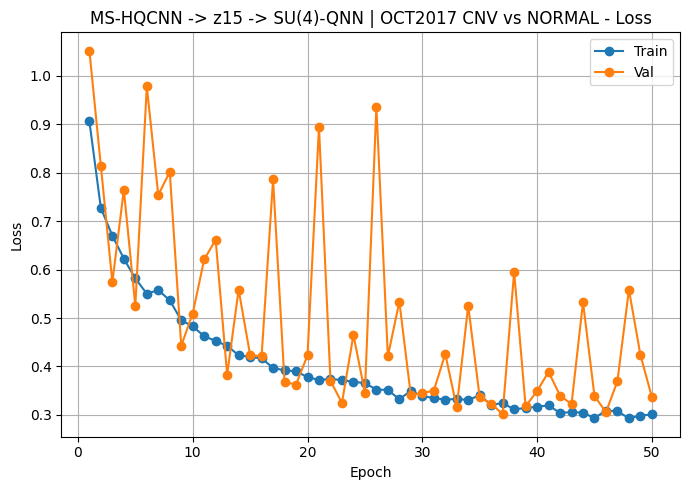

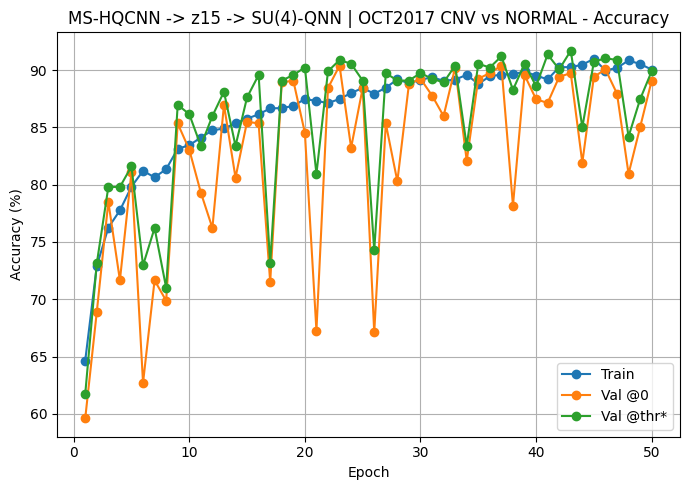


[OK] Sección 8 lista


In [57]:
history_df = pd.DataFrame(history)
history_path = os.path.join(TABLE_DIR, "training_history.csv")
history_df.to_csv(history_path, index=False)
print("\n[Entrenamiento terminado]")
print(f"Best epoch    : {best_epoch}\nBest val bAcc : {best_val_bacc}\nBest q_thr    : {best_threshold}\nHistory saved : {history_path}")
plot_history(history, fig_dir=FIG_DIR, prefix="train")
print("\n[OK] Sección 8 lista")

# **9) Evaluación final en test**

## 9.1) Cargar mejor checkpoint


In [58]:
print("[Evaluación final]")
print("Cargando:", best_ckpt_path)
best_ckpt = load_model_state_from_checkpoint(model, best_ckpt_path, map_location=DEVICE)
best_threshold = best_ckpt.get("threshold", 0.0)
print(f"Best epoch : {best_ckpt['epoch']}\nBest q_thr : {best_threshold}")

[Evaluación final]
Cargando: Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\checkpoints\best_model.pt
Best epoch : 43
Best q_thr : 0.13502595989141875


C:\Users\lapic\AppData\Local\Temp\ipykernel_5004\1718183569.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=map_location)


## 9.2) Evaluar train / val / test


In [59]:
train_loss_final, train_eval_final, train_y_final, train_q_final = evaluate_loader(model=model, loader=train_loader, device=DEVICE)
val_loss_final, val_eval_final, val_y_final, val_q_final = evaluate_loader(model=model, loader=val_loader, device=DEVICE)
test_loss_final, test_eval_final, test_y_final, test_q_final = evaluate_loader(model=model, loader=test_loader, device=DEVICE)

## 9.3) Métricas con threshold óptimo de validación


In [60]:
def metrics_with_fixed_q_threshold(y_true_bipolar, q_scores, q_threshold):
    y_true_bipolar, q_scores = np.asarray(y_true_bipolar).astype(int), np.asarray(q_scores).astype(float)
    y_true_01, probs = bipolar_to_binary(y_true_bipolar), qscore_to_probs(q_scores)
    return binary_metrics_from_probs(y_true_01, probs, threshold=0.5 * (q_threshold + 1.0))

train_fixed = metrics_with_fixed_q_threshold(train_y_final, train_q_final, best_threshold)
val_fixed = metrics_with_fixed_q_threshold(val_y_final, val_q_final, best_threshold)
test_fixed = metrics_with_fixed_q_threshold(test_y_final, test_q_final, best_threshold)

## 9.4) Tabla resumen


In [61]:
final_rows = []
for split_name, loss_value, eval_value, fixed_value in [("train", train_loss_final, train_eval_final, train_fixed), ("val", val_loss_final, val_eval_final, val_fixed), ("test", test_loss_final, test_eval_final, test_fixed)]:
    final_rows.append({"split": split_name, "loss": loss_value, "auc": eval_value["auc"], "pr_auc": eval_value["pr_auc"], "acc_at_0": eval_value["m05"]["acc"], "f1_at_0": eval_value["m05"]["f1"], "bacc_at_0": eval_value["m05"]["bacc"], "acc_at_val_thr": fixed_value["acc"], "f1_at_val_thr": fixed_value["f1"], "bacc_at_val_thr": fixed_value["bacc"], "sensitivity_at_val_thr": fixed_value["sensitivity"], "specificity_at_val_thr": fixed_value["specificity"], "pred1_at_val_thr": fixed_value["pred1"], "q_threshold": best_threshold})
final_metrics_df = pd.DataFrame(final_rows)
final_metrics_path = os.path.join(TABLE_DIR, "final_metrics.csv")
final_metrics_df.to_csv(final_metrics_path, index=False)
print("\n[Final metrics]"); display(final_metrics_df); print("Saved:", final_metrics_path)


[Final metrics]


,split,loss,auc,pr_auc,acc_at_0,f1_at_0,bacc_at_0,acc_at_val_thr,f1_at_val_thr,bacc_at_val_thr,sensitivity_at_val_thr,specificity_at_val_thr,pred1_at_val_thr,q_threshold
0,train,0.262241,0.975849,0.973894,0.919732,0.922267,0.919852,0.926630,0.927224,0.926668,0.937919,0.915417,0.509824,0.135026
1,val,0.322555,0.963132,0.954438,0.897394,0.905547,0.895892,0.916938,0.921899,0.915966,0.958599,0.873333,0.552117,0.135026
2,test,0.338511,0.953300,0.947221,0.892027,0.896000,0.891909,0.897010,0.898026,0.896987,0.903974,0.890000,0.508306,0.135026


Saved: Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\tables\final_metrics.csv


## 9.5) Classification report test


In [62]:
test_pred_bipolar = np.where(test_q_final >= best_threshold, LABEL_POS, LABEL_NEG)
test_true_01, test_pred_01 = bipolar_to_binary(test_y_final), bipolar_to_binary(test_pred_bipolar)
print("\n[Classification report - test @ val threshold]")
print(classification_report(test_true_01, test_pred_01, target_names=TARGET_NAMES, zero_division=0))


[Classification report - test @ val threshold]
              precision    recall  f1-score   support

      NORMAL       0.90      0.89      0.90       300
         CNV       0.89      0.90      0.90       302

    accuracy                           0.90       602
   macro avg       0.90      0.90      0.90       602
weighted avg       0.90      0.90      0.90       602



## 9.6) Guardar predicciones


In [63]:
def save_split_predictions(split_name, y_true, q_scores, q_threshold):
    y_true, q_scores = np.asarray(y_true).astype(int), np.asarray(q_scores).astype(float)
    probs, y_pred = qscore_to_probs(q_scores), np.where(q_scores >= q_threshold, LABEL_POS, LABEL_NEG).astype(int)
    df = pd.DataFrame({"y_true": y_true, "q_score": q_scores, "prob_positive": probs, "y_pred": y_pred, "q_threshold": q_threshold})
    path = os.path.join(TABLE_DIR, f"{split_name}_predictions.csv")
    df.to_csv(path, index=False); return df, path

train_pred_df, train_pred_path = save_split_predictions("train", train_y_final, train_q_final, best_threshold)
val_pred_df, val_pred_path = save_split_predictions("val", val_y_final, val_q_final, best_threshold)
test_pred_df, test_pred_path = save_split_predictions("test", test_y_final, test_q_final, best_threshold)
print("\n[Predicciones guardadas]")
print(train_pred_path); print(val_pred_path); print(test_pred_path)


[Predicciones guardadas]
Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\tables\train_predictions.csv
Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\tables\val_predictions.csv
Results\OCT2017_CNV_NORMAL_MS_HQCNN_z15_SU4_QNN\tables\test_predictions.csv


## 9.7) Curvas finales test


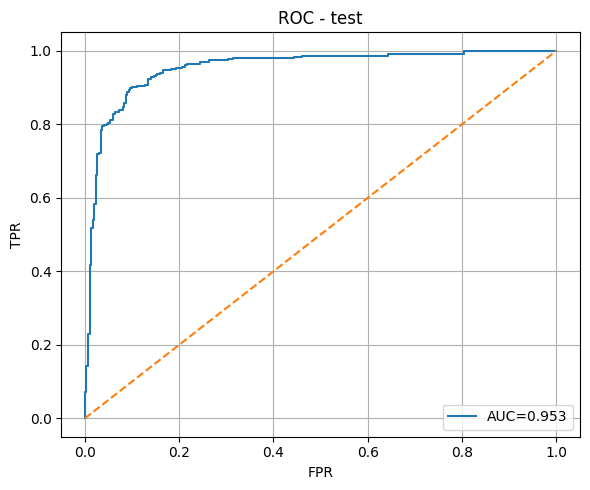

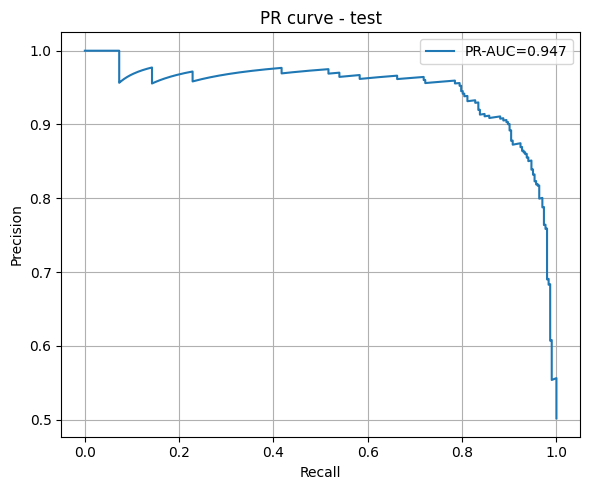

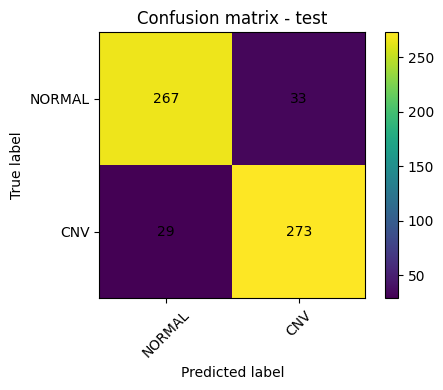


[OK] Sección 9 lista


In [64]:
plot_eval_curves(y_true_bipolar=test_y_final, q_scores=test_q_final, threshold=best_threshold, split_name="test", fig_dir=FIG_DIR, prefix="final")
print("\n[OK] Sección 9 lista")